In [1]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import subprocess
import sys

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [3]:
import numpy as np                                #para operações matemáticas e processamento de matrizes(Euclidiana, Hamming e a Canberra Modificada)
import pandas as pd                               #manipulação de dados tabulares
from sklearn.preprocessing import StandardScaler  #escalonamento de dados para garantir que todas as variáveis contribuam igualmente
import matplotlib.pyplot as plt                   #para gerar todos os gráficos e mapas de calor
import seaborn as sns                             
%matplotlib inline                                
import warnings                                   #suprimir avisos de sistema durante a execução
warnings.filterwarnings('ignore')                 
import tensorflow as tf                           #bibliotecas de Deep Learning
from tensorflow import keras                      #Facilita criar redes neurais
import umap.umap_ as umap                         #importa o umap usado
%config InlineBackend.figure_format = 'svg'
from cluster_val import calcular_anova

In [4]:
#Importa os algorimos e medidas usadas no processo
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified
from fdc.clustering import *

from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from cluster_val import *

Importando os dados pré-processados

In [5]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data=pd.read_csv('../Datasets/heart_failure_clinical_records_dataset.csv')

In [6]:
np.random.seed(42)
data=data.sample(frac=1) #Embaralha o dataset
np.random.seed(42)
i=[x for x in range(299)]
data.set_index(pd.Series(i), inplace=True)

In [7]:
data.drop('DEATH_EVENT',axis=1,inplace=True)

data.shape

(299, 12)

In [8]:
#Importa funções e classes do FDC
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified
from fdc.clustering import *

UMAP nos dados originais

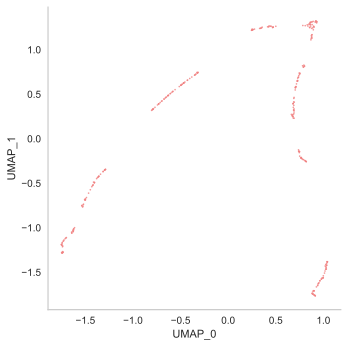

In [9]:
umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering K-means

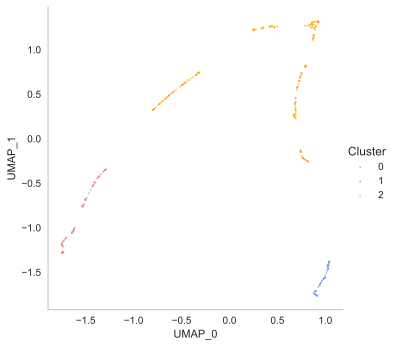

In [10]:
umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(3)

In [11]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.7215150593855391

Visualizar Silhouette score (Pode-se escolher o números de clusters baseados no resultado)

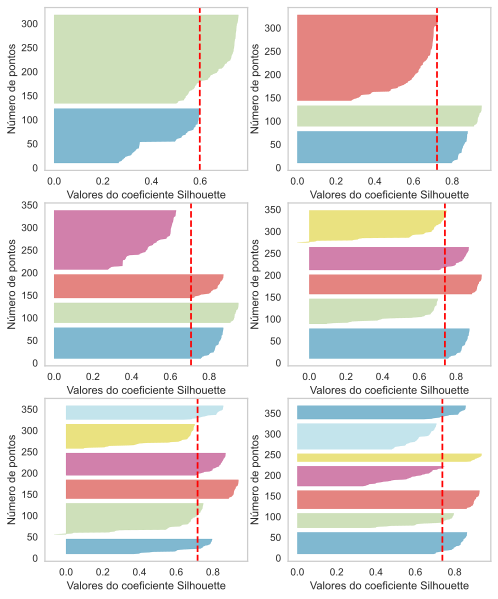

In [12]:
Silhouette_visual(umap_emb)

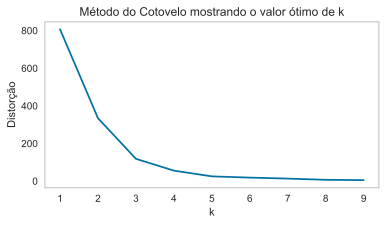

In [13]:
elbow_plot(umap_emb)

In [14]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.5718464185734525

Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering Aglomerativo

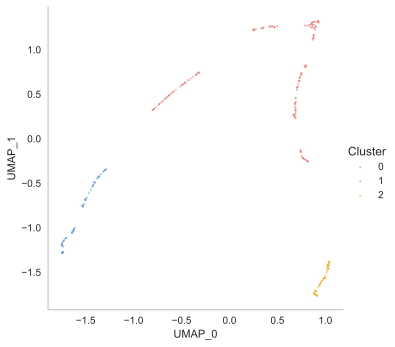

In [15]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(3,'euclidean','ward')

In [16]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.7208239842145473

In [17]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.4100306336964232

Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering DBSCAN 

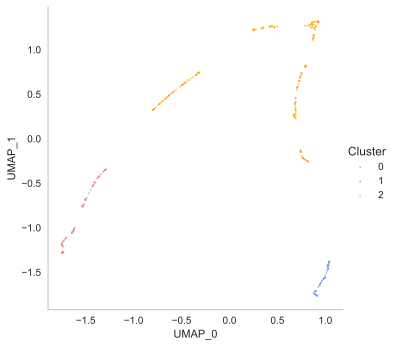

In [18]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.8,20)

In [19]:
#Remove os indices considerados ruídos pelo algoritmo
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]

In [20]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.7215150593855391

In [21]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.5718464185734525

Dividindo as variaveis
- cont_list = contínuas
- ord_list = ordinais

In [22]:
cont_list= ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium','time']

ord_list= ['anaemia','diabetes','high_blood_pressure','sex','smoking']

In [23]:
len(ord_list)

5

In [24]:
len(cont_list)

7

Aplicando FDC nos dados originais

In [25]:
#Importa e renomeia a classe Clustering correta da fdc para evitar conflito
from fdc.fdc import Clustering as ClusteringNorm
from fdc.fdc import FDC

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 1.20312 / 1.203s
FDC.normalize (clustering ORD): 4.90625 / 6.109s
FDC.normalize (clustering NOM): 0.00000 / 6.109s
FDC.normalize (concat): 0.00000 / 6.109s
FDC.normalize (umap 5 -> 2): 0.90625 / 7.016s
FDC.normalize (array -> DataFrame): 0.00000 / 7.016s


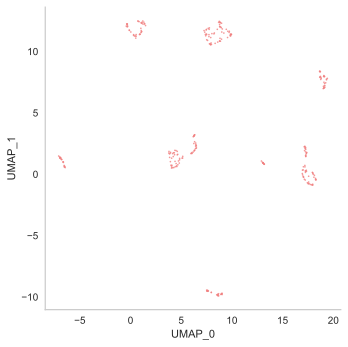

FDC.normalize (plotting): 1.89062 / 8.906s
FDC.normalize (array -> DataFrame): 0.00000 / 8.906s
FDC.normalize (total): 0.00000 / 8.906s


In [26]:
fdc = FDC(clustering_cont=ClusteringNorm('euclidean', 15, 0.1, 2)  #número de vizinhos e parâmetro de densidade
          , clustering_ord=ClusteringNorm(modified_can, 15, 0.1, 1)  #usa Canberra modificada que é mais sensível a valores pequenos
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True #projeção 2D
          )

fdc.selectFeatures(continueous=cont_list, ordinal=ord_list) #diz ao modelo quais variáveis são contínuas e quais são ordinais

FDC_emb_high,FDC_emb_low = fdc.normalize(data,
                                        n_neighbors=15,         #numero de vizinhos
                                        min_dist=0.1,           #o quão proximo os clusters vão ficar
                                        cont_list=cont_list,
                                        ord_list=ord_list,
                                        with_2d_embedding=True, #Gera duas representações, uma de alta e outra de baixa dimensão
                                        visual=True)

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando k-means

In [27]:
FDC_emb_high_original = FDC_emb_high.copy()
FDC_emb_low_original = FDC_emb_low.copy()
#cópias necessárias

In [28]:
FDC_emb_high

,CONT_UMAP_0,CONT_UMAP_1,ORD_UMAP_0
0,-1.536987,-1.674952,-2.112931
1,1.296260,-0.845582,0.458014
2,1.307582,-0.512285,0.195879
3,1.123930,-1.008214,0.508309
4,-0.998469,0.564259,0.275413
...,...,...,...
294,-0.845849,-0.625078,0.740659
295,-1.508947,-1.535532,0.312235
296,0.314475,1.032073,-0.089296
297,0.383123,1.106979,0.353981


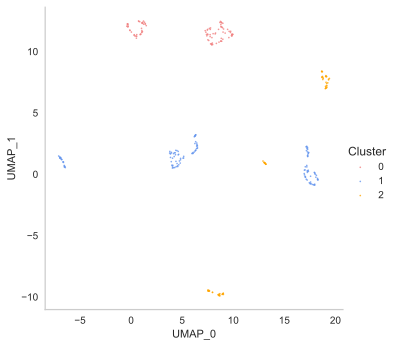

Pacientes perdidos como ruído: 25 de 299
Clusters encontrados: 4


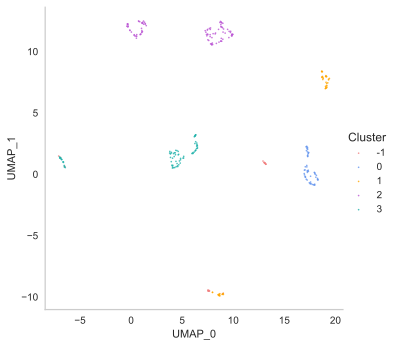

In [29]:
from fdc.clustering import Clustering

clustering=Clustering(FDC_emb_high,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(3)
# HDBSCAN - melhoria proposta, resolve o problema de perda de pacientes do DBSCAN
hdbscan_cluster_list, hdbscan_cluster_counts = clustering.HDBSCAN(min_cluster_size=15)

In [30]:
FDC_emb_high['Cluster'] = cluster_list

silhouette_score(FDC_emb_high, cluster_list, metric='euclidean')

0.4857403119123685

In [31]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list))

0.19487003663612668

Visualizando Shilhouette score para FDC embedding de baixa dimensão

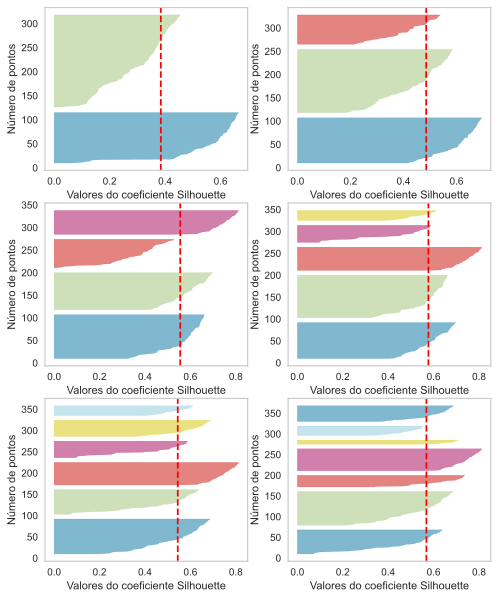

In [32]:
Silhouette_visual(FDC_emb_high)

Elbow plot para FDC embedding de baixa dimensão

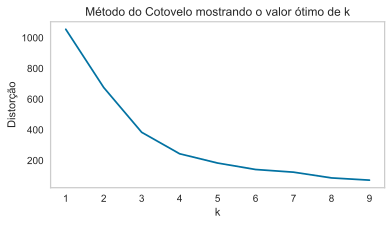

In [33]:
elbow_plot(FDC_emb_high)

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering aglomerativo

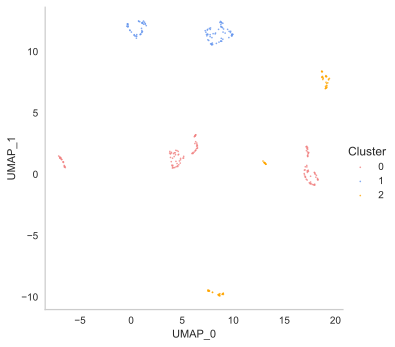

In [34]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(3,'euclidean','ward')

In [35]:
FDC_emb_high['Cluster'] = cluster_list_agglo

silhouette_score(FDC_emb_high, cluster_list_agglo, metric='euclidean')

0.4889920020136737

In [36]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_agglo))

0.19487003663612668

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering do DBSCAN

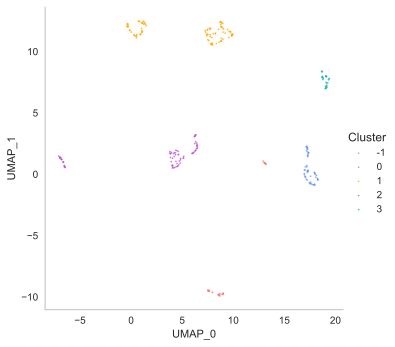

In [37]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(0.8,20)

In [38]:
FDC_emb_high['Cluster'] = cluster_list_dbscan

In [39]:
#Remove os indices considerados ruídos pelo algoritmo
non_noise_indices= np.where(np.array(cluster_list_dbscan)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list_dbscan= np.array(cluster_list_dbscan)[non_noise_indices]

In [40]:
silhouette_score(FDC_emb_high, cluster_list_dbscan, metric='euclidean')

0.6503987576789153

In [41]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_dbscan))

0.31235040527481206

In [42]:
print("Tamanho dos dados:", len(FDC_emb_high_original))
print("Tamanho do DBSCAN:", len(cluster_list_dbscan))

Tamanho dos dados: 299
Tamanho do DBSCAN: 262


In [43]:
# 1. Filtra ruído do HDBSCAN para calcular métricas
non_noise_hdbscan = [i for i, x in enumerate(hdbscan_cluster_list) if x != -1]
hdbscan_emb = FDC_emb_high_original.iloc[non_noise_hdbscan]
hdbscan_labels = [hdbscan_cluster_list[i] for i in non_noise_hdbscan]
hdbscan_data = data.iloc[non_noise_hdbscan]

# 2. Filtra ruído do DBSCAN para calcular métricas
non_noise_dbscan = [i for i, x in enumerate(cluster_list_dbscan) if x != -1]
dbscan_emb = FDC_emb_high_original.iloc[non_noise_dbscan]
dbscan_labels = [cluster_list_dbscan[i] for i in non_noise_dbscan]
dbscan_data = data.iloc[non_noise_dbscan]

# 3. Dicionário de Resultados
resultados = {
    'K-means': {
        'Silhouette': round(silhouette_score(FDC_emb_high_original, cluster_list), 3),
        'Dunn': round(dunn_index(cluster_wise_df(
                    pd.DataFrame(FDC_emb_high_original).assign(Cluster=cluster_list),
                    cluster_list)), 3),
        'ANOVA (% features significativas)': calcular_anova(
                    data, cluster_list, cont_list, ord_list),
        'Pacientes perdidos': 0
    },
    'DBSCAN': {
        # Usando as variáveis filtradas (_emb e _labels) para as métricas
        'Silhouette': round(silhouette_score(dbscan_emb, dbscan_labels), 3),
        'Dunn': round(dunn_index(cluster_wise_df(
                    pd.DataFrame(dbscan_emb).assign(Cluster=dbscan_labels),
                    dbscan_labels)), 3),
        'ANOVA (% features significativas)': calcular_anova(
                    dbscan_data, dbscan_labels, cont_list, ord_list),
        # Usando a lista original para contar o total de perdas
        'Pacientes perdidos': sum(1 for x in cluster_list_dbscan if x == -1)
    },
    'HDBSCAN': {
        'Silhouette': round(silhouette_score(hdbscan_emb, hdbscan_labels), 3),
        'Dunn': round(dunn_index(cluster_wise_df(
                    pd.DataFrame(hdbscan_emb).assign(Cluster=hdbscan_labels),
                    hdbscan_labels)), 3),
        'ANOVA (% features significativas)': calcular_anova(
                    hdbscan_data, hdbscan_labels, cont_list, ord_list),
        'Pacientes perdidos': sum(1 for x in hdbscan_cluster_list if x == -1)
    }
}

pd.DataFrame(resultados).T

,Silhouette,Dunn,ANOVA (% features significativas),Pacientes perdidos
K-means,0.433,0.195,66.67,0.0
DBSCAN,-0.072,0.002,8.33,0.0
HDBSCAN,0.573,0.259,41.67,25.0
